# PyTorch Standard

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(device)

mps


In [56]:

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

class LR(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LR, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.fc(x)
        return self.sigmoid(x)
    
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return self.sigmoid(x)

def get_data(input_dim = 20, output_dim = 1, n_samples = 10, batch_size = 32):
    X = torch.randn(n_samples, input_dim)
    y = torch.randint(0, 2, (n_samples, 1)).float()
    train_dataset = TensorDataset(X, y)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    eval_loader = DataLoader(train_dataset, batch_size=batch_size)
    test_loader = DataLoader(train_dataset, batch_size=batch_size)
    return train_loader, eval_loader, test_loader

def train_eval_model(model, train_loader, eval_loader, criterion, optimizer, epochs=10):
    model.train()
    for epoch in range(1, epochs+1):
        print(f"Epoch {epoch}")
        train_loss = 0.0
        train_accuracy = 0.0
        for batch_idx, (X, y) in enumerate(train_loader):
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_pred = model(X)
            # Swapped the arguments so that the predicted outputs come first.
            loss = criterion(y_pred, y)
            loss.backward()
            optimizer.step()
            # if batch_idx % 10 == 0:
            #     print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item()}')
            train_loss += loss.sum().item()
            y_pred = (y_pred > 0.5).float()
            train_accuracy += (y_pred == y).sum().item()
        print(f"Train Accuracy: {train_accuracy/len(train_loader.dataset): .4f}, Train Loss: {train_loss / len(train_loader.dataset): .4f} (Pre-backward)")
        
        model.eval()
        eval_loss = 0.0
        eval_accuracy = 0.0
        with torch.no_grad():
            for batch_idx, (X, y) in enumerate(eval_loader):
                X, y = X.to(device), y.to(device)
                y_prob = model(X)
                eval_loss += criterion(y_prob, y).sum().item()
                y_pred = (y_prob > 0.5).float()
                eval_accuracy += (y_pred == y).sum().item()
            print(f"Eval Accuracy: {eval_accuracy/len(eval_loader.dataset):.4f}, Eval Loss: {eval_loss/len(eval_loader.dataset):.4f}")
    return model

def test(model, test_loader):
    print("Test")
    model.eval()
    eval_loss = 0.0
    eval_accuracy = 0.0
    with torch.no_grad():
        for _, (X, y) in enumerate(test_loader):
            X, y = X.to(device), y.to(device)
            y_prob = model(X)
            loss = criterion(y_prob, y)
            eval_loss += loss.sum().item()
            y_pred = (y_prob > 0.5).float()
            eval_accuracy += (y_pred == y).sum().item()
    print(f"Test Accuracy: {eval_accuracy/len(test_loader.dataset):.4f}, Test Loss: {eval_loss/len(test_loader.dataset):.4f}")
    return

input_dim = 20
output_dim = 1
n_samples = 10
batch_size = 32
model = LR(input_dim, output_dim).to(device)
criterion = nn.BCELoss()
# crazy learning rate to overfitting test
optimizer = optim.SGD(model.parameters(), lr=1)
train_loader, eval_loader, test_loader = get_data(input_dim, output_dim, n_samples, batch_size)
model = train_eval_model(model, train_loader, eval_loader, criterion, optimizer, epochs=2)
test(model, test_loader)

Epoch 1
Train Accuracy:  0.5000, Train Loss:  0.0689 (Pre-backward)
Eval Accuracy: 0.8000, Eval Loss: 0.0377
Epoch 2
Train Accuracy:  0.8000, Train Loss:  0.0377 (Pre-backward)
Eval Accuracy: 1.0000, Eval Loss: 0.0258
Test
Test Accuracy: 1.0000, Test Loss: 0.0258


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")


In [3]:

# Define VAE model
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc21 = nn.Linear(hidden_dim, latent_dim)
        self.fc22 = nn.Linear(hidden_dim, latent_dim)
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Define loss function
def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# Define training function
def train(model, optimizer, train_loader, epochs):
    model.train()
    for epoch in range(epochs):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = loss_function(recon_batch, data, mu, logvar)
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
            if batch_idx % 100 == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, batch_idx * len(data), len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item() / len(data)))

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.,), (1.,))
])
train_loader = DataLoader(datasets.MNIST('../../data', train=True, download=True, transform=transform), batch_size=128, shuffle=True)

# Instantiate VAE model
input_dim = 784
hidden_dim = 400
latent_dim = 20
model = VAE(input_dim, hidden_dim, latent_dim).to(device)

# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Train model
train(model, optimizer, train_loader, epochs=1)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 9.90MB/s]


Extracting ../../data/MNIST/raw/train-images-idx3-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 324kB/s]


Extracting ../../data/MNIST/raw/train-labels-idx1-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.62MB/s]


Extracting ../../data/MNIST/raw/t10k-images-idx3-ubyte.gz to ../../data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.54MB/s]


Extracting ../../data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ../../data/MNIST/raw

Train Epoch: 0 [0/60000 (0%)]	Loss: 545.175964
Train Epoch: 0 [12800/60000 (21%)]	Loss: 186.434738
Train Epoch: 0 [25600/60000 (43%)]	Loss: 152.248108
Train Epoch: 0 [38400/60000 (64%)]	Loss: 138.359039
Train Epoch: 0 [51200/60000 (85%)]	Loss: 135.286758


In [4]:
device

device(type='mps')

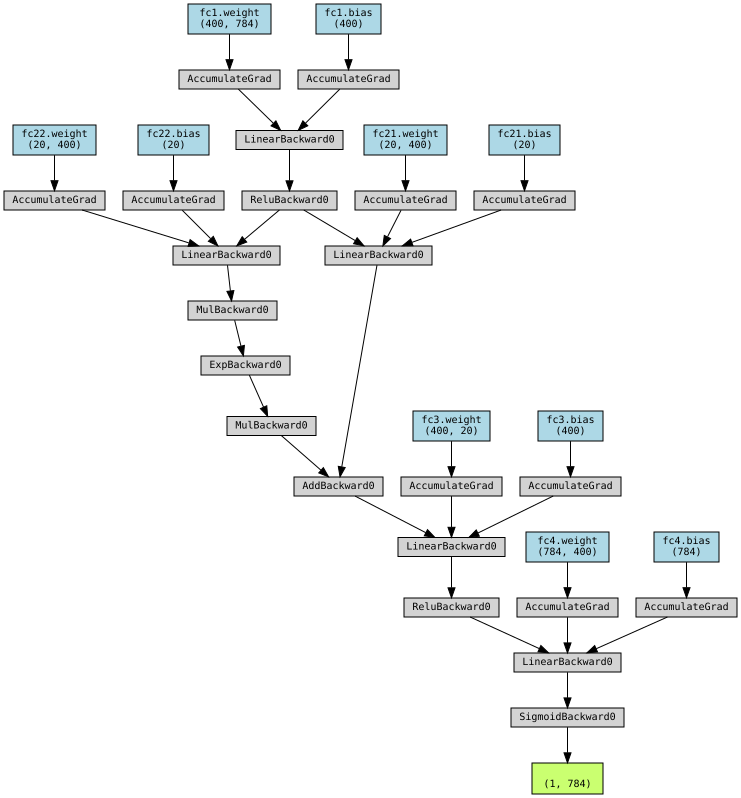

In [6]:
import torchviz 
import torch.nn.functional as F 

sample_input = torch.randn(1, 784).to(device)
model = VAE(input_dim, hidden_dim, latent_dim).to(device)
recon_batch, mu, logvar = model(sample_input)

torchviz.make_dot(recon_batch, params=dict(model.named_parameters()))

In [8]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [9]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 26.4M/26.4M [01:54<00:00, 231kB/s] 


Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 144kB/s]


Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:05<00:00, 743kB/s]


Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 9.54MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [10]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [ ]:
# Get cpu or gpu device for training.
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
epochs = 3
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

In [ ]:
model = NeuralNetwork()
model.load_state_dict(torch.load("model.pth"))

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    pred = model(x)
    print(f'pred: "{pred}"')
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define the encoder-decoder model
class EncoderDecoderModel(nn.Module):
    def __init__(self, input_size, hidden_size, latent_size):
        super(EncoderDecoderModel, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, latent_size),
            nn.ReLU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 3)  # Output 3 values for a, b, and c
        )

    def forward(self, x):
        latent = self.encoder(x)
        outputs = self.decoder(latent)
        a, b, c = outputs[:, 0], outputs[:, 1], outputs[:, 2]
        return a, b, c

# Objective function
def loss1(a, b, c):
    return -(a * 2 + b * 5 + c * 3).mean()

def loss2(a, b, c):
    return ((a + b + c - 10) ** 2).mean() * 1000.

def loss3(a, b, c):
    penalty = torch.relu(-a) + torch.relu(-b) + torch.relu(-c)
    return penalty.mean() * 1000.  # Large penalty to enforce non-negativity

# Initialize the model
input_size = 1  # Dummy input size, since we're directly optimizing a, b, and c
hidden_size = 10
latent_size = 5
model = EncoderDecoderModel(input_size, hidden_size, latent_size)

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 10000
batch_size = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Dummy input for the batch (all ones to simulate intercept learning)
    x_dummy = torch.ones(batch_size, input_size)
    
    # Forward pass
    a, b, c = model(x_dummy)
    
    # Compute losses
    obj_loss = loss1(a, b, c)
    const_loss = loss2(a, b, c)
    non_neg_penalty = loss3(a, b, c)
    
    # Combine losses with weights
    combined_loss = obj_loss + const_loss + non_neg_penalty
    combined_loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Combined Loss: {combined_loss.item():.4f}, Objective Loss: {obj_loss.item():.4f}, Constraint Loss: {const_loss.item():.4f}, Penalty: {non_neg_penalty.item():.4f}, a: {a.mean().item():.4f}, b: {b.mean().item():.4f}, c: {c.mean().item():.4f}')

# Final optimized values (using a single input to get final values)
x_dummy = torch.ones(1, input_size)  # Single input to get final values
a_opt, b_opt, c_opt = model(x_dummy)
print(f'Optimized values - a: {a_opt.item():.4f}, b: {b_opt.item():.4f}, c: {c_opt.item():.4f}')


Epoch [100/10000], Combined Loss: -31.6805, Objective Loss: -31.6870, Constraint Loss: 0.0064, Penalty: 0.0000, a: 3.9742, b: 2.8268, c: 3.2015
Epoch [200/10000], Combined Loss: -31.6968, Objective Loss: -31.7049, Constraint Loss: 0.0081, Penalty: 0.0000, a: 3.9696, b: 2.8330, c: 3.2002
Epoch [300/10000], Combined Loss: -31.7248, Objective Loss: -31.7274, Constraint Loss: 0.0027, Penalty: 0.0000, a: 3.9611, b: 2.8418, c: 3.1988
Epoch [400/10000], Combined Loss: -31.7570, Objective Loss: -31.7596, Constraint Loss: 0.0026, Penalty: 0.0000, a: 3.9511, b: 2.8530, c: 3.1975
Epoch [500/10000], Combined Loss: -31.7946, Objective Loss: -31.7973, Constraint Loss: 0.0026, Penalty: 0.0000, a: 3.9396, b: 2.8660, c: 3.1961
Epoch [600/10000], Combined Loss: -31.8374, Objective Loss: -31.8400, Constraint Loss: 0.0026, Penalty: 0.0000, a: 3.9264, b: 2.8808, c: 3.1944
Epoch [700/10000], Combined Loss: -31.8853, Objective Loss: -31.8880, Constraint Loss: 0.0026, Penalty: 0.0000, a: 3.9116, b: 2.8974, c: